## Lecture 10

## Python Parallel Computing - Part 01

### Apr 8, 2026


Part of this lecture is based on this material from previous years: https://nyu-cds.github.io/python-mpi/




You will need **mpi4py** 

To install: [https://mpi4py.readthedocs.io/en/stable/install.html](https://mpi4py.readthedocs.io/en/stable/install.html)
 
 https://nyu-cds.github.io/python-mpi/setup/

Run the following in terminal: <br><br>

1. sudo apt install libopenmpi-dev <br><br>

2. pip install mpi4py <br><br>


or 

1. brew install open-mpi <br><br>

2. pip install mpi4py <br><br>




**Definitions**

- **Program**: An executable file residing on disk <br><br>

- **Process**: One or more executing instances of a program. Processes have separate address spaces. <br><br>

-  **Task**: In MPI (Message Passing Interface), a process is sometimes called a task, but these are used interchangably. We will always use “process” rather than “task”. <br><br>

- **Thread (or lightweight process)**: One or more threads of control within a process. Threads share the same address space. <br><br>


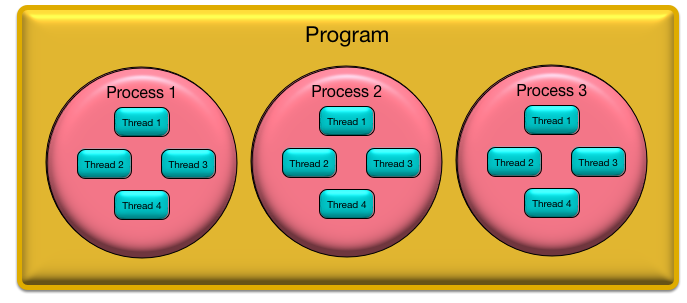




**What is parallel computing?**

Traditionally, software has been written for serial computation: <br><br>

- A problem is broken into a discrete series of instructions <br><br>
- Instructions are executed sequentially one after another <br><br>
- Executed on a single processor  <br><br>
- Only one instruction may execute at any moment in time <br><br>

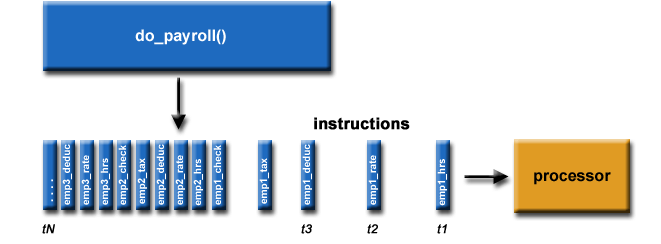

In the simplest sense, parallel computing is the simultaneous use of multiple compute resources to solve a computational problem: <br><br>

- A problem is broken into discrete parts that can be solved concurrently <br><br>
- Each part is further broken down to a series of instructions <br><br>
- Instructions from each part execute simultaneously on different processors <br><br>
- An overall control/coordination mechanism is employed <br><br>

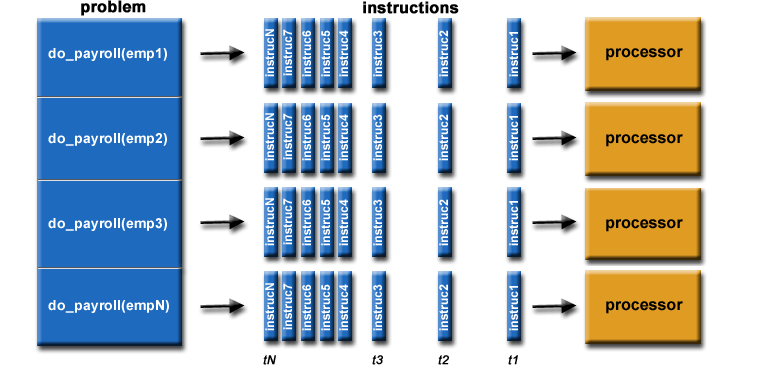

**Why do we need parallel programming?**

Need to solve larger problems: 
- Require more memory 
- Computation takes much longer
- Huge amounts of data may be required <br><br>

Parallel programming provides <br><br>

- More CPU resources <br><br>
- More memory resources <br><br>
- The ability to solve problems that were not possible with serial program <br><br>
- The ability to solve problems more quickly <br><br>

**Two basic approaches**

<img src="./figs/shared_memory.png" alt="shared_memory" style="width: 450px;"/>


<img src="./figs/distributed_memory.png" alt="distributed_memory" style="width: 500px;"/>

**Parallel programming models**

Directive-based parallel programming language

- OpenMP (most widely used) <br><br>
- High Performance Fortran (HPF) is another example <br><br>
  - Directives tell processor how to distribute data and work across the processors <br><br>
  - Directives appear as comments in the serial code <br><br>
  - Implemented on shared memory architectures <br><br>

Message Passing

- MPI (most widely used) <br><br>
  - Pass messages to send/receive data between processes <br><br>
  - Each process has its own local variables <br><br>
  - Can be used on either shared or distributed memory architectures <br><br>

**Pros and cons**

Pros of OpenMP <br><br>

- Easier to program and debug than MPI <br><br>
- Directives can be added incrementally - gradual parallelization <br><br>
- Can still run the program as a serial code <br><br>
- Serial code statements usually don’t need modification <br><br>
- Code is easier to understand and maybe more easily maintained <br><br>

Cons of OpenMP

- Can only be run in shared memory computers <br><br>
- Requires a compiler that supports OpenMP <br><br>
- Mostly used for loop parallelization <br><br>

**Pros of MPI**

- Runs on either shared or distributed memory architectures <br><br>
- Can be used on a wider range of problems than OpenMP <br><br>
- Each process has its own local variables <br><br>
- Distributed memory computers are less expensive than large shared memory computers <br><br>

**Cons of MPI**

- Requires more programming changes to go from serial to parallel version <br><br>
- Can be harder to debug <br><br>
- Performance is limited by the communcation network between the nodes <br><br>

**Parallel programming issues**

Goal is to reduce execution time

- Computation time <br><br>
- Idle time - waiting for data from other processors <br><br>
- Communication time - time the processors take to send and receive messages <br><br>

Load Balancing

- Divide the work equally among the available processors <br><br>

Minimizing Communication

- Reduce the number of messages passed <br><br>
- Reduce amount of data passed in messages <br><br>

Where possible - overlap communication and computation <br><br>

Many problems scale well to only a limited number of processors

## Parallelization and Amdahl's law

* Want to leverage parallelization as much as possible <br><br>
* Often we cannot obtain perfect (linear) speedups, e.g., communication or global logic <br><br>
* Amdahl's law is a simple law to get an idea of the speedup: <br><br>
    - $N$: number of processors <br><br>
    - $P$: fraction of program that can be parallelized <br><br>
    - $speedup$: is the theoretical speedup of the execution of the whole program <br><br>

$$
speedup = \frac{1}{(1 - P) + \frac{P}{N}}
$$

<img src="https://nyu-cds.github.io/python-mpi/fig/01-amdahls-law.png" alt="amdahls" style="width: 300px;"/>

Basically this is saying that the amount of speedup a program will see by using n cores is based on how much of the program is serial (can only be run on a single CPU core) and how much of it is parallel (can be split up among multiple CPU cores). <br><br>

**Programming approaches**

Two main approaches:

SPMD - Single Program, Multiple Data Streams <br><br>

- Each processor is executing the same program on different data <br><br> 
- A parallel execution model that assumes multiple cooperating processes executing a program <br><br>
- The most common style of parallel programming and the one used by MPI <br><br>

MPMD - Multiple Programs, Multiple Data Streams

- Multiple processors executing at least two independent programs <br><br>
- Manager/worker strategies fit into this category <br><br>
- Web browser and web server is another example <br><br>

**What is MPI?**

MPI stands for Message Passing Interface <br><br>

- Library of functions (C/C++) or subroutines (Fortran) <br><br>

History

- Early message passing Argonne’s P4 and Oak Ridge PVM in 1980s <br><br>
- MPI-1 completed in 1994 (1.1 - 1995, 1.2 - ?, 1.3 - 2008) <br><br>
- MPI-2 completed in 1998 (2.1 - 2008, 2.2 - 2009) <br><br>
- MPI-3 completed in 2012 (3.1 - 2015) <br><br>
- MPI-3 features gradually added to MPI implementations <br><br>

**Version differences**

Examples of Different Implementations

- MPICH - developed by Argonne Nationa Labs (freeware) <br><br>
- MPI/LAM - developed by Indiana, OSC, Notre Dame (freeware) <br><br>
- MPI/Pro - commerical product <br><br>
- Apple’s X Grid <br><br>
- OpenMPI - MPI-2 compliant, thread safe <br><br>

Similiarities in Various Implementations

- Source code compatibility (except parallel I/O) <br><br>
- Programs should compile and run as is <br><br>
- Support for heterogeneous parallel architectures <br><br>


Difference in Various Implementations

- Commands for compiling and linking <br><br>
- How to launch an MPI program <br><br>
- Parallel I/O (from MPI-2) <br><br>
- Debugging <br><br>

---

### __MPI__ (Message Passing Interface) 

- Widely used standard <br><br>


- For programming **distributed-memory**, **multiple instruction**--**multiple data** (MIMD) systems <br><br>


#### __Point to point Communication__

Processes should coordinate their activities by explicitly sending and receiving messages

MPI operates as follows:
- Process A decides a message needs to be sent to process B. <br><br>
- Process A packs up all of its necessary data into a buffer for process B. <br><br>
- Process A indicates that the data should be sent to process B by calling the _Send_ function. <br><br>
- Process B needs to acknowledge it wants to receive the message by calling the _Recv_ function. <br><br>

Every time a process sends a message, there must be a process that also indicates it wants to receive the message, therefore, calls to _Send_ and _Recv_ are always paired. <br><br>



<img src="./figs/send_receive.png" alt="distributed_memory" style="width: 400px;"/>


### The number of processes 

- Is **fixed** when an MPI program is started  <br><br>

- Each of the processes is assigned a unique integer starting from 0.  <br><br>

- This integer is know as the **rank** of the process and  <br><br>
  - is how each process is identified when sending and receiving messages (we will refer to rank K process as "process K").

- **MPI processes** are arranged in logical collections known as **communicators**. <br><br>

- There is one special communicator (**`MPI.COMM_WORLD`**) that exists when an MPI program starts, which contains all the processes in the MPI program. <br><br>


- MPI provides a few **methods** on a communicator: <br><br>


> `Get_size()` - returns the total number of processes contained in the communicator (the size of the communicator). <br><br>

> `Get_rank()` - returns the rank of the calling process within the communicator, between 0 and (size-1) <br><br>

> `Send()` - sends content to a process <br><br>

> `Recv()` - receives content from a process <br><br>



The following code obtains the size of the `MPI.COMM_WORLD` communicator, and rank of the process within the communicator. <br><br>

We will create a file called mpi1.py and run this code to see what the values of size and rank are for each process. <br><br>

In [1]:
from mpi4py import MPI

comm = MPI.COMM_WORLD
size = comm.Get_size()
rank = comm.Get_rank()
print('hello world: size = %d, rank = %d' % (size, rank))

hello world: size = 1, rank = 0


In [2]:
%%writefile mpi1.py
#####
# writing the code in the mpi1.py file
#####

from mpi4py import MPI

comm = MPI.COMM_WORLD
size = comm.Get_size()
rank = comm.Get_rank()
print('hello world: size = {}, rank = {}'.format(size, rank))

Overwriting mpi1.py


In [3]:
#####
# running MPI from the terminal with n=4 processes
# does not work in notebook for me for some reason, if so you can run in the terminal
#####

!mpiexec -n 4 python mpi1.py

hello world: size = 4, rank = 0
hello world: size = 4, rank = 1
hello world: size = 4, rank = 2
hello world: size = 4, rank = 3


---
### One MPI program, multiple MPI processes
Making each process to perform a different computation

- When an MPI program is run, each process consists of the same code. However, as we’ve seen, there is one, and only one,  difference:  <br><br>
  - each process is assigned a different rank value. This allows code for each process to be embedded within one program file. <br><br>

In the following code, all processes start with the same two numbers a and b. 

However, although there is only one file, each process performs a different computation on the numbers. 

Process 0 prints the sum of the numbers, process 1 prints the result of multiplying the numbers, and process 2 prints the maximum value.

Create a program called mpi2.py containing the code below.

In [4]:
%%writefile mpi2.py

from mpi4py import MPI
rank = MPI.COMM_WORLD.Get_rank()

a = 8.0
b = 4.0

print('Process rank',rank)

if rank == 0:
        print("addition:", a + b)

if rank == 1:
        print("multiplication:", a * b)

if rank == 2:
        print("maximum:", max(a,b))
        
if rank == 3:
        print("doing nothing:")

Overwriting mpi2.py


Run this program using the command:

In [5]:
!mpiexec -n 4 python mpi2.py

Process rank 1
multiplication: Process rank 2
maximum: 8.0
32.0
Process rank 0
addition: 12.0
Process rank 3
doing nothing:


---
### Point-to-point communication

As mentioned in earlier, the simplest message passing involves two processes: a sender and a receiver.  <br><br>

Let us begin by demonstrating a program designed for two processes.  <br><br>

One will draw a random number and then send it to the other.  <br><br>

- We will do this using the routines Send and Recv. <br><br>

Message passing involves two processes: a **sender** and a **receiver** (commands _Send_ and _Recv_). <br><br>


Create a program called mpi3.py containing the code below.

In [6]:
%%writefile mpi3.py
#####
# Sending a message from one process to another
#####
import numpy

from mpi4py import MPI
comm = MPI.COMM_WORLD
rank = comm.Get_rank()

randNum = numpy.zeros(1)

if rank == 1:
        print("part of Process", rank, "- before receiving has the number", randNum[0])
        # generates a numpy array with one element unif. distr. from [0,1)
        randNum = numpy.random.rand(1)
        print("part of Process", rank, "- drew the number", randNum[0])
        comm.Send(randNum, dest=0)
        
if rank == 0:
        print("part of Process", rank, "- before receiving has the number", randNum[0])
        comm.Recv(randNum, source=1)
        print("part of Process", rank, "- received the number", randNum[0])

Overwriting mpi3.py


Run this program using the command:

In [7]:
!mpiexec -n 2 python mpi3.py

part of Process 0 - before receiving has the number 0.0
part of Process 1 - before receiving has the number 0.0
part of Process 1 - drew the number 0.8432439567935907
part of Process 0 - received the number 0.8432439567935907


The Send and Recv functions are referred to as blocking functions (we will look at non-blocking functions later).  <br><br>

If a process calls Recv it will simply wait until a message from the corresponding Send is received before proceeding. <br><br>
 
Similarly the Send will wait until the message has been reveived by the corresponding Recv. <br><br>

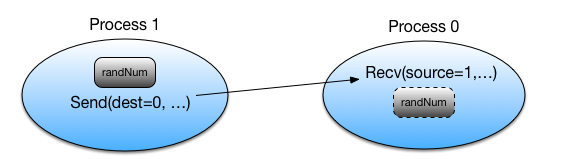

**More Send and Recv**

Previously, we saw how to send a message from one process to another. <br><br>
Now we’re going to try sending a message to a process and receiving a message back again. <br><br>

Let’s modify the previous code so that when the process 0 receives the number, it multiplies it by twenty and sends it back to process 1. Process 1 should then print out the new value. <br><br>

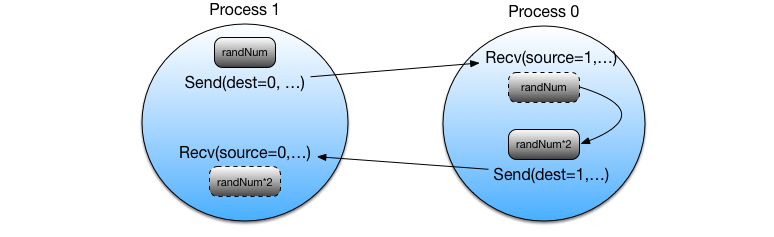

Create a new program called mpi4.py with the following code:

In [8]:
%%writefile mpi4.py
#####
# Sending a message to a process and receiving a message back
#####

import numpy
from mpi4py import MPI
comm = MPI.COMM_WORLD
rank = comm.Get_rank()

randNum = numpy.zeros(1) 

if rank == 1:
        randNum = numpy.random.rand(1)
        print("Process", rank, "drew the number", randNum[0])
        comm.Send(randNum, dest=0)
        comm.Recv(randNum, source=0)
        print("Process", rank, "received the number", randNum[0], "from process 0")
        
if rank == 0:
        print("Process", rank, "before receiving has the number", randNum[0])
        comm.Recv(randNum, source=1)
        print("Process", rank, "received the number", randNum[0], "from process 1")
        randNum *= 20
        comm.Send(randNum, dest=1) 

Overwriting mpi4.py


In [9]:
!mpiexec -n 2 python mpi4.py

Process 0 before receiving has the number 0.0
Process 1 drew the number 0.7778270827634518
Process 0 received the number 0.7778270827634518 from process 1
Process 1 received the number 15.556541655269037 from process 0



- The receiving process does not always need to specify the source when issuing a Recv. <br><br>

- Instead, the process can accept **any message** that is being sent by another process. This is done by setting the source to **MPI.ANY_SOURCE**. <br><br>

We can try replacing the source=N arguments in your program with source=MPI.ANY_SOURCE to see if it still works.

In [10]:
%%writefile mpi5.py
#####
# Sending a message to a process and receiving a message back from MPI.ANY_SOURCE
#####

import numpy
from mpi4py import MPI

comm = MPI.COMM_WORLD
rank = comm.Get_rank()

randNum = numpy.zeros(1) 

if rank == 1:
        randNum = numpy.random.random_sample(1)
        print("Process", rank, "drew the number", randNum[0])
        comm.Send(randNum, dest=0)
        comm.Recv(randNum, source=MPI.ANY_SOURCE)
        print("Process", rank, "received the number", randNum[0])
        
if rank == 0:
        print("Process", rank, "before receiving has the number", randNum[0])
        comm.Recv(randNum, source=MPI.ANY_SOURCE)
        print("Process", rank, "received the number", randNum[0])    
        randNum *= 2
        comm.Send(randNum, dest=1)

Overwriting mpi5.py


Now we should see output like the following:

In [11]:
!mpiexec -n 2 python mpi5.py

Process 0 before receiving has the number 0.0
Process 1 drew the number 0.8303839379480457
Process 0 received the number 0.8303839379480457
Process 1 received the number 1.6607678758960913


---

- Sometimes there are cases when a process might have to **send many different types of messages to another process**.  <br><br>
- Instead of having to go through extra measures to differentiate all these messages, MPI allows senders and receivers to also **specify message IDs (known as tags)** with the message. <br><br> 
- The receiving process can then request a message with a certain tag number and messages with different tags will be buffered until the process requests them. <br><br>

Here are the actual definitions of the Send method:
```python
Comm.Send(buf, dest=0, tag=0)
```
- Performs a basic send.  <br><br>
- This send is a point-to-point communication.  <br><br>
- It sends information from exactly one process to exactly one other process. <br><br>

Parameters:

- Comm (MPI comm) – communicator we wish to query <br><br>
- buf (choice) – data to send <br><br>
- dest (integer) – rank of destination <br><br>
- tag (integer) – message tag <br><br>

Here are the actual definitions of the Recv method:

```python
Comm.Recv(buf, source=0, tag=0, status=None) 
```
Performs a point-to-point receive of data. <br><br>

Parameters:

- Comm (MPI comm) – communicator we wish to query <br><br>
- buf (choice) – initial address of receive buffer (choose receipt location) <br><br>
- source (integer) – rank of source <br><br>
- tag (integer) – message tag <br><br>
- status (Status) - status of object <br><br>
  - The _status_ can provide useful information:


```python
info = MPI.Status()
source = info.Get_source()
tag = info.Get_tag()
count = info.Get_elements()
size = info.Get_count()
```

In [12]:
%%writefile mpi_tag.py
from mpi4py import MPI

comm = MPI.COMM_WORLD
size = comm.Get_size()
rank = comm.Get_rank() 

data1 = None
data2 = None

if rank == 0:
    data1 = ('a','b', 'c', 'd')
    data2 = (1, 2, 3, 4)
    
    comm.send(data1, dest=1, tag=0)    
    comm.send(data2, dest=1, tag=1)
    
    

elif rank == 1:
    print('On Process',rank,'before recv: data1 = ', data1)
    print('On Process',rank,'before recv: data2 = ', data2)
    
    data1 = comm.recv(source=0, tag=0)  
    data2 = comm.recv(source=0, tag=1)
    
    print('On Process',rank,'after  recv: data1 = ', data1)
    print('On Process',rank,'after  recv: data2 = ', data2)
    

Overwriting mpi_tag.py


In [13]:
!mpiexec -n 2 python mpi_tag.py

On Process 1 before recv: data1 =  None
On Process 1 before recv: data2 =  None
On Process 1 after  recv: data1 =  ('a', 'b', 'c', 'd')
On Process 1 after  recv: data2 =  (1, 2, 3, 4)


Sending a message from one process to another:

In [14]:
%%writefile mpi_status.py
#####
# Sending a message from one process to another
#####


import numpy
from mpi4py import MPI
comm = MPI.COMM_WORLD
rank = comm.Get_rank()

info = MPI.Status()
# print("info: ", info)

randNum = numpy.zeros(1)

if rank == 1:
        randNum = numpy.random.random_sample(1)
        print("Process", rank, "drew the number", randNum[0])
        comm.Send(randNum, dest=0)

if rank == 0:
        print("Process", rank, "before receiving has the number", randNum[0])
        comm.Recv(randNum, source=1, status=info)
        print("Process", rank, "received the number", randNum[0], "from Process", info.Get_source())

Overwriting mpi_status.py


You should see output similar to the following:

In [15]:
!mpiexec -n 2 python mpi_status.py

Process 0 before receiving has the number 0.0
Process 1 drew the number 0.11634694296977688
Process 0 received the number 0.11634694296977688 from Process 1



### Non-blocking Communication

So far we have seen how to send and receive messages using blocking communication. <br><br>
In the previous examples, the sender and receiver are not able to perform any action when sending or receiving a message. <br><br>
This can waste computation time while waiting for the call to complete. <br><br> 

__Non-blocking communcation__ avoids this issue by using the `Isend(...)` and `Irecv(...)` methods, which start to send and receive operations and then return immediately to continue computation. <br><br>

The completion of a send or receive operation can be managed using the _Test_, _Wait_, and _Cancel_ methods. <br><br>

- These methods return a instance of the `Request` class, which uniquely identifys the started operation. <br><br> 
- The completion can then be managed using the Test, Wait, and Cancel methods of the `Request` class.  <br><br>
- The management of `Request` objects and associated memory buffers involved in c ommunication requires careful coordination.  <br><br>
- Users must ensure that objects exposing their memory buffers are not accessed at the Python level while they are involved in nonblocking message-passing operations. <br><br>


The following example performs the same simple blocking send and receive as demonstrated previously, however this time it is done with the non-blocking versions of the send and receive methods. <br><br>
The calls to `Wait()` immediately following the non-blocking methods will block the process until the corresponding send and receives have completed. <br><br>

In [ ]:
%%writefile mpi6.py
#####
# this code is similar to mpi3.py, 
# but it uses Wait to block the processes
#####

import numpy
from mpi4py import MPI
comm = MPI.COMM_WORLD
rank = comm.Get_rank()

randNum = numpy.zeros(1)

if rank == 1:
        randNum = numpy.random.random_sample(1)
        print("Process", rank, "drew the number", randNum[0])
        
        req = comm.Isend(randNum, dest=0)
        req.Wait()
        
        print('something here')
        
if rank == 0:
        print("Process", rank, "before receiving has the number", randNum[0])
        
        req = comm.Irecv(randNum, source=1)
        req.Wait()
        
        print("Process", rank, "received the number", randNum[0])

Overwriting mpi6.py


In [17]:
!mpiexec -n 2 python mpi6.py

Process 0 before receiving has the number 0.0
Process 1 drew the number 0.8411630154962738
something here
Process 0 received the number 0.8411630154962738


### Overlap communication


**Example:** Process 1 overlaps a computation with sending the message and receiving the reply. The computation divides `randNum` by 10 and prints the result.

In [ ]:
%%writefile mpi7.py
#####
# overlap communication
#####

import numpy
from mpi4py import MPI
comm = MPI.COMM_WORLD
rank = comm.Get_rank()

randNum = numpy.zeros(1) 

if rank == 1:
        randNum = numpy.array([50], dtype=numpy.float64)
        print("Process", rank, "drew the number", randNum[0])
        
        comm.Isend(randNum, dest=0)
        
        randNum[0] /= 10 # overlap communication
        print("Process", rank, "number in overlap communication =", randNum[0])
        
        req = comm.Irecv(randNum, source=0)
#         req.Wait()
        print("Process", rank, "received the number", randNum[0])

if rank == 0:
        print("Process", rank, "before receiving has the number", randNum[0])
        req = comm.Irecv(randNum, source=1)
#         req.Wait()
        print("Process", rank, "received the number", randNum[0])
        randNum *= 2
        comm.Isend(randNum, dest=1)

Overwriting mpi7.py


In [21]:
!mpiexec -n 2 python mpi7.py

Process 0 before receiving has the number 0.0Process 1 drew the number 50.0

Process 1 number in overlap communication =Process  5.0
0 received the number 50.0
Process 1 received the number 100.0


Try running with and without commenting out the `req.Wait()` lines in the above code; both are actually unsafe. Though we uncomment the `req.Wait()` lines, we are modifying the `randNum` variable (the same buffer) before the send finishes.

So the takeaway is that overlap communication means doing computation while sending (or communication is still in progress), but we should **never modify the same data buffer until communication finishes**.